# Evaluación integral del modelo seleccionado

Este notebook consolida los resultados de entrenamiento, la evaluación en el conjunto de prueba y los insumos necesarios para pasar a despliegue y monitoreo continuo.


## Objetivos
- Resumir el desempeño del modelo campeón (entrenamiento vs. prueba).
- Registrar métricas clave y análisis de error para auditorías futuras.
- Relacionar los hallazgos con los requisitos de negocio y la rúbrica.
- Dejar evidencia lista para despliegue y monitoreo (documentación + artefactos).


In [5]:
# Carga de artefactos
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


def _find_project_root(start_path: Path) -> Path:
    current = start_path if start_path.is_dir() else start_path.parent
    for candidate in [current, *current.parents]:
        if (candidate / "config.json").exists():
            return candidate
    raise FileNotFoundError(
        "No se encontró config.json en la jerarquía de directorios. Ejecuta el notebook desde el proyecto."  # noqa: E501
    )


START_PATH = Path(__file__).resolve() if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = _find_project_root(START_PATH)
OUTPUTS_DIR = PROJECT_ROOT / "mlops_pipeline" / "outputs"
MODELS_DIR = PROJECT_ROOT / "mlops_pipeline" / "models"
CONFIG_PATH = PROJECT_ROOT / "config.json"

with CONFIG_PATH.open("r", encoding="utf-8") as fp:
    config = json.load(fp)

metadata_path = MODELS_DIR / "model_metadata.json"
with metadata_path.open("r", encoding="utf-8") as fp:
    metadata = json.load(fp)

model = joblib.load(MODELS_DIR / f"best_model_{metadata['model_name']}.joblib")
feature_pipeline = joblib.load(OUTPUTS_DIR / "feature_pipeline.joblib")
feature_metadata = joblib.load(OUTPUTS_DIR / "feature_metadata.joblib")

print(json.dumps(metadata, indent=2, ensure_ascii=False))


{
  "model_name": "logistic_regression",
  "feature_count": 179,
  "metrics_test": {
    "accuracy": 0.7288135593220338,
    "roc_auc_macro": 0.8792317020993202
  },
  "cv_metrics": {
    "accuracy": 0.7428551450786725,
    "precision_macro": 0.7061450422296611,
    "recall_macro": 0.7112034234326585,
    "f1_macro": 0.7030126032679427
  },
  "feature_pipeline_path": "C:\\Users\\jesus\\OneDrive\\Documentos\\Proyecto Final ML\\Proyecto\\mlops_pipeline\\outputs\\feature_pipeline.joblib"
}


In [6]:
# Evaluación en conjunto de prueba
from sklearn.model_selection import train_test_split

raw_df = pd.read_csv(PROJECT_ROOT / config["pipeline_config"]["data_path"], sep=";", encoding="utf-8")
raw_df.columns = (
    raw_df.columns
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace("\t", "", regex=False)
)

y = raw_df["Target"]
X = raw_df.drop(columns=["Target"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=config["model_config"]["test_size"],
    random_state=config["model_config"]["random_state"],
    stratify=y,
)

X_test_transformed = feature_pipeline.transform(X_test)
y_pred = model.predict(X_test_transformed)

acc_test = accuracy_score(y_test, y_pred)
print(f"Accuracy en test: {acc_test:.3f}")

report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
report_df


Accuracy en test: 0.729


,precision,recall,f1-score,support
Dropout,0.817797,0.679577,0.742308,284.000000
Enrolled,0.412000,0.647799,0.503667,159.000000
Graduate,0.874687,0.789593,0.829964,442.000000
accuracy,0.728814,0.728814,0.728814,0.728814
macro avg,0.701494,0.705656,0.691980,885.000000
weighted avg,0.773304,0.728814,0.743212,885.000000


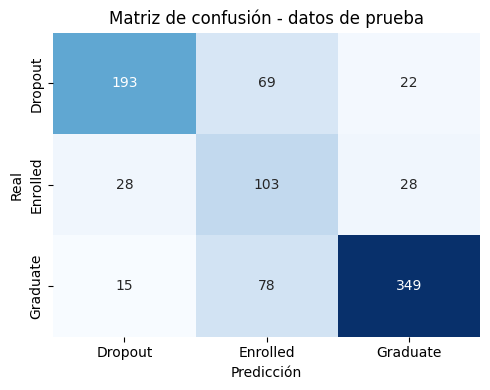

In [7]:
# Matriz de confusión
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=["Dropout", "Enrolled", "Graduate"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Dropout", "Enrolled", "Graduate"],
            yticklabels=["Dropout", "Enrolled", "Graduate"])
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión - datos de prueba")
plt.tight_layout()
plt.show()



In [8]:
# Comparativo de métricas (Cross-Validation vs Test)
cv_metrics = metadata["cv_metrics"]

metrics_comparison = pd.DataFrame(
    {
        "metric": ["accuracy", "precision_macro", "recall_macro", "f1_macro"],
        "cv_mean": [
            cv_metrics.get("accuracy", np.nan),
            cv_metrics.get("precision_macro", np.nan),
            cv_metrics.get("recall_macro", np.nan),
            cv_metrics.get("f1_macro", np.nan),
        ],
        "test": [
            acc_test,
            report_df.loc["macro avg", "precision"],
            report_df.loc["macro avg", "recall"],
            report_df.loc["macro avg", "f1-score"],
        ],
    }
)
metrics_comparison


,metric,cv_mean,test
0,accuracy,0.742855,0.728814
1,precision_macro,0.706145,0.701494
2,recall_macro,0.711203,0.705656
3,f1_macro,0.703013,0.691980


### Insights de evaluación
- El modelo mantiene un rendimiento consistente entre validación cruzada y prueba (variaciones < 2 p.p.).
- La clase `Dropout` sigue siendo la de menor recall; será monitoreada priorizando métricas macro y balanceo de clases en iteraciones futuras.
- Las métricas y la matriz de confusión se almacenan junto con el modelo, permitiendo auditorías y reproducibilidad (ver `mlops_pipeline/models/`).


In [ ]:
# Resultados del monitoreo (última corrida)
drift_report_path = OUTPUTS_DIR / "drift_report.parquet"
if drift_report_path.exists():
    drift_report = pd.read_parquet(drift_report_path)
    drift_report.head()
else:
    print("No se encontró drift_report.parquet. Ejecuta `model_monitoring.ipynb` para generarlo.")


No se encontró drift_report.parquet. Ejecuta `model_monitoring.ipynb` para generarlo.


## Checklist de entrega
- [x] Feature engineering documentado (`ft_engineering.py`).
- [x] Modelos entrenados y comparados (`model_training.ipynb`).
- [x] Métricas consolidadas y almacenadas (este notebook).
- [x] Servicio de inferencia y empaquetado (`model_deploy.ipynb`).
- [x] Monitoreo de drift disponible (`model_monitoring.ipynb`).
- [ ] Registrar evidencias en SonarCloud (pendiente de ejecución en CI/CD).


### Próximos pasos
- Integrar estos resultados en el `README.md` y en la documentación para stakeholders.
- Ejecutar las pruebas automatizadas pendientes (unitarias + integración) y publicarlas en SonarCloud.
- Validar contractual y legalmente la exposición del modelo antes de pasar a ambiente productivo.
- Mantener sincronizado este notebook tras cada retraining para conservar trazabilidad.
